/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2016/3975560634.py:3: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



DEUTSCH ALGORITHM - BALANCED FUNCTION

Oracle Circuit:
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

Complete Deutsch Circuit:
     ┌───┐          ┌───┐
q_0: ┤ H ├───────■──┤ H ├
     ├───┤┌───┐┌─┴─┐└───┘
q_1: ┤ X ├┤ H ├┤ X ├─────
     └───┘└───┘└───┘     

MEASUREMENT RESULTS
Shots : 1000
0 count : 0
1 count : 1000
P(0) : 0.0000
P(1) : 1.0000

RESULT: 1
The function is BALANCED.


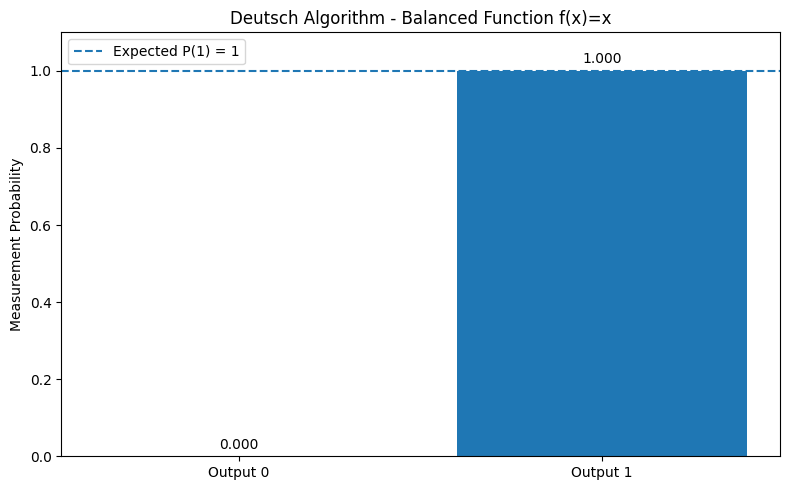

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

SHOTS = 1000

# ---------------------------------------------------------
# BALANCED ORACLE: f(x) = x
# ---------------------------------------------------------

def balanced_oracle():
    oracle = QuantumCircuit(2)

    # f(x) = x
    # CNOT implements y -> y XOR x
    oracle.cx(0, 1)

    return oracle


# ---------------------------------------------------------
# DEUTSCH ALGORITHM
# ---------------------------------------------------------

qc = QuantumCircuit(2)

# Initial state |0>|1>
qc.x(1)

# Superposition
qc.h(0)
qc.h(1)

# Balanced oracle
oracle = balanced_oracle()
qc.compose(oracle, inplace=True)

# Interference
qc.h(0)

print("\nDEUTSCH ALGORITHM - BALANCED FUNCTION")
print("=" * 60)

print("\nOracle Circuit:")
print(oracle.draw())

print("\nComplete Deutsch Circuit:")
print(qc.draw())

# ---------------------------------------------------------
# STATEVECTOR SIMULATION
# ---------------------------------------------------------

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

p0 = 0.0
p1 = 0.0

for index, probability in enumerate(probabilities):
    bit = format(index, "02b")
    q0 = bit[-1]

    if q0 == "0":
        p0 += probability
    else:
        p1 += probability

# ---------------------------------------------------------
# MEASUREMENTS
# ---------------------------------------------------------

rng = np.random.default_rng(42)

samples = rng.choice(
    [0, 1],
    size=SHOTS,
    p=[p0, p1]
)

count_0 = int(np.sum(samples == 0))
count_1 = int(np.sum(samples == 1))

print("\nMEASUREMENT RESULTS")
print("=" * 60)

print(f"Shots : {SHOTS}")
print(f"0 count : {count_0}")
print(f"1 count : {count_1}")
print(f"P(0) : {count_0 / SHOTS:.4f}")
print(f"P(1) : {count_1 / SHOTS:.4f}")

if count_0 > count_1:
    print("\nRESULT: 0")
    print("The function is CONSTANT.")
else:
    print("\nRESULT: 1")
    print("The function is BALANCED.")

# ---------------------------------------------------------
# GRAPH
# ---------------------------------------------------------

labels = ["Output 0", "Output 1"]
values = [count_0 / SHOTS, count_1 / SHOTS]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.axhline(
    1.0,
    linestyle="--",
    label="Expected P(1) = 1"
)

plt.ylabel("Measurement Probability")
plt.title("Deutsch Algorithm - Balanced Function f(x)=x")
plt.ylim(0, 1.1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()